## Plot available ACA header 3 MSIDs for validation / sanity check

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
from ska_matplotlib import plot_cxctime

sys.path.insert(0, "..")
from mica.archive import aca_hdr3

%matplotlib inline

In [2]:
# Configure matplotlib for smaller file sizes
plt.rcParams["figure.dpi"] = 72
plt.rcParams["savefig.dpi"] = 72
%config InlineBackend.figure_format = 'jpg'

In [3]:
msids = [hdr3["msid"] for hdr3 in aca_hdr3.HDR3_DEF.values() if "value" in hdr3]
msids = sorted(msids)
msids

['aca_temp',
 'ad_15v_ps',
 'ad_27v_ps',
 'ad_5v_ps',
 'ad_achhs_therm',
 'ad_achohs_therm',
 'ad_analog_gnd',
 'ad_converter_therm',
 'ad_lc_therm',
 'ad_m15v_ps',
 'ad_pmhs_therm',
 'ad_pmohs_therm',
 'ad_smhs_therm',
 'ad_smohs_therm',
 'avg_bkg',
 'ccd_det_therm',
 'ccd_molyb_therm_1',
 'ccd_molyb_therm_2',
 'ccd_setpoint',
 'ccd_temp',
 'dac',
 'zero_off16_quad_a',
 'zero_off16_quad_b',
 'zero_off16_quad_c',
 'zero_off16_quad_d']

In [4]:
# Read all MSIDs as a set
dat = aca_hdr3.MSIDset(msids, "2026:001:00:00:00", "2026:003:00:00:00")

In [5]:
np.array([len(dat[msid].vals) for msid in msids])

array([41925, 41949, 41949, 41961, 41945, 41945, 41949, 41949, 41945,
       41949, 41945, 41945, 41949, 41945, 41962, 41961, 41961, 41961,
       41925, 41960, 41925, 41962, 41962, 41962, 41966])

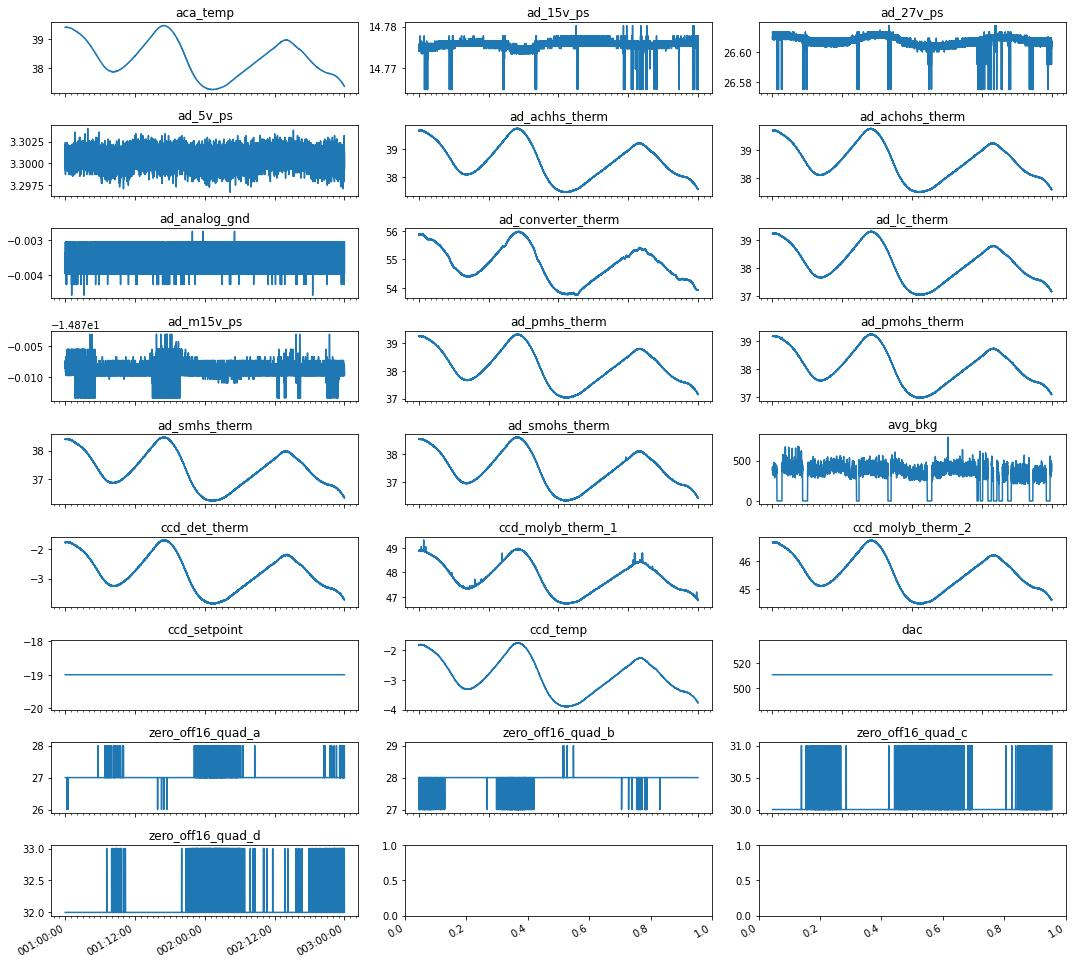

In [6]:
n_msids = len(msids)
ncols = 3
nrows = int(np.ceil(n_msids / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 1.5 * nrows))
for msid, ax in zip(msids, axes.flatten()):
    plot_cxctime(dat[msid].times, dat[msid].vals, ax=ax)
    ax.set_title(msid)
fig.tight_layout()